In [1]:
%cd /mnt/sdd1/atharvas/formulacode/datasmith
import datetime
import json
from pathlib import Path

import docker

from datasmith.docker.context import ContextRegistry, DockerContext, Task
from datasmith.notebooks.utils import merge_registries, update_cr

curr_date: str = datetime.datetime.now().isoformat()

/mnt/sdd1/atharvas/formulacode/datasmith


11:18:06 WARNING  simple_useragent.core: Falling back to historic user agent.


In [2]:
results_pth = Path("scratch/")

registries = results_pth.rglob("**/*context_registry*.json")
merged_json = merge_registries(list(registries))
registry = update_cr(ContextRegistry.deserialize(payload=json.dumps(merged_json)))

In [3]:
len({k: v for k, v in registry.registry.items() if len(v.building_data)})

6404

In [4]:
import datetime


def within_3_months(unix_time: float) -> bool:
    one_month_ago = datetime.datetime.now() - datetime.timedelta(days=30)
    return datetime.datetime.fromtimestamp(unix_time) >= one_month_ago


valid_registry = {
    k: v for k, v in registry.registry.items() if len(v.building_data) and within_3_months(v.created_unix)
}
len(valid_registry)

953

In [5]:
import pandas as pd

df1 = pd.read_parquet("scratch/artifacts/processed/perfonly_commits_with_patch_full.parquet")
df2 = pd.read_parquet("scratch/artifacts/pipeflush/perfonly_commits_with_patch.parquet")
df3 = pd.read_parquet("scratch/artifacts/processed/perfonly_commits_numpy_with_patch.parquet")

print(df1.shape, df2.shape, df3.shape)
fin_df = pd.concat([df1, df2, df3]).drop_duplicates(subset=["pr_merge_commit_sha"])
fin_df.shape

(1072, 161) (2923, 161) (131, 161)


(3214, 161)

In [9]:
# old_fin_df = pd.read_parquet("scratch/artifacts/processed/perfonly_commits_with_patch_final.parquet")
# old_fin_df.shape
fin_df.to_parquet("scratch/artifacts/processed/perfonly_commits_with_patch_final.parquet")

In [8]:
old_fin_df["pr_merge_commit_sha"].isin(fin_df["pr_merge_commit_sha"]).sum()

np.int64(3121)

In [ ]:
# df = pd.read_parquet("scratch/artifacts/processed/perfonly_commits_with_patch_full.parquet")
# df['container_name'] = (df['repo_name'].str.replace("/", "-") + "-" + df['pr_base_sha'] + ":run")
# !ls -lash scratch/artifacts/pipeflush/*.parquet
fin_df = pd.read_parquet("scratch/artifacts/pipeflush/commits_filtered.parquet")
fin_df.shape

scratch/artifacts/pipeflush/commits_filtered.parquet
scratch/artifacts/pipeflush/commits_perfonly.parquet
scratch/artifacts/pipeflush/filtered_commits_perfonly.parquet
scratch/artifacts/pipeflush/merge_commits_filtered_2.parquet
scratch/artifacts/pipeflush/merge_commits_filtered.parquet
scratch/artifacts/pipeflush/merge_commits_filtered_with_patch.parquet
scratch/artifacts/pipeflush/perfonly_commits_with_patch.bak.parquet
scratch/artifacts/pipeflush/perfonly_commits_with_patch.parquet
scratch/artifacts/pipeflush/perfonly_commits_with_patch.raw.parquet
scratch/artifacts/pipeflush/perfonly_commits_with_patch_sm.bak.parquet
scratch/artifacts/pipeflush/perfonly_commits_with_patch_sm.parquet
scratch/artifacts/pipeflush/perfonly_commits_with_patch_sm.raw.parquet


In [1]:
# set(fin_df['repo_name'].unique())

In [ ]:
fin_df = pd.read_parquet("scratch/artifacts/pipeflush/merge_commits_filtered_2.parquet")

In [5]:
import pandas as pd

df = pd.read_parquet("scratch/artifacts/processed/perfonly_commits_with_patch_full.parquet")
df["container_name"] = df["repo_name"].str.replace("/", "-") + "-" + df["pr_base_sha"] + ":run"


dfbak = pd.read_parquet("scratch/artifacts/pipeflush/perfonly_commits_with_patch.parquet")
dfbak["container_name"] = dfbak["repo_name"].str.replace("/", "-") + "-" + dfbak["pr_base_sha"] + ":run"

fulldf = pd.concat([df, dfbak]).reset_index(drop=True)

In [6]:
# print(df['repo_name'].unique()), print(dfbak['repo_name'].unique())

In [7]:
uniq_df = df.drop_duplicates(subset=["container_name"])
uniq_df.shape

(979, 161)

In [8]:
imgs = {k.with_tag("run").get_image_name() for k in valid_registry}
imgs_not_in_df = imgs - set(uniq_df["container_name"].unique())
shas_not_in_df = set(map(lambda x: x.replace(":run", "").split("-")[-1], imgs_not_in_df))

uniq_df[uniq_df["container_name"].isin(imgs)].shape

(152, 161)

In [14]:
imgs = {k.with_tag("run").get_image_name() for k in valid_registry}


imgs_not_in_df = imgs - set(uniq_df["container_name"].unique())
shas_not_in_df = set(map(lambda x: x.replace(":run", "").split("-")[-1], imgs_not_in_df))

fin_df = uniq_df[uniq_df["container_name"].isin(imgs)]

['astropy/astropy' 'scipy/scipy' 'scikit-learn/scikit-learn'
 'pandas-dev/pandas' 'pymc-devs/pymc3']


In [52]:
fin_df.shape  # [#'pr_merge_commit_sha'].nuniq()

(597, 161)

<Axes: ylabel='pr_merge_commit_sha'>

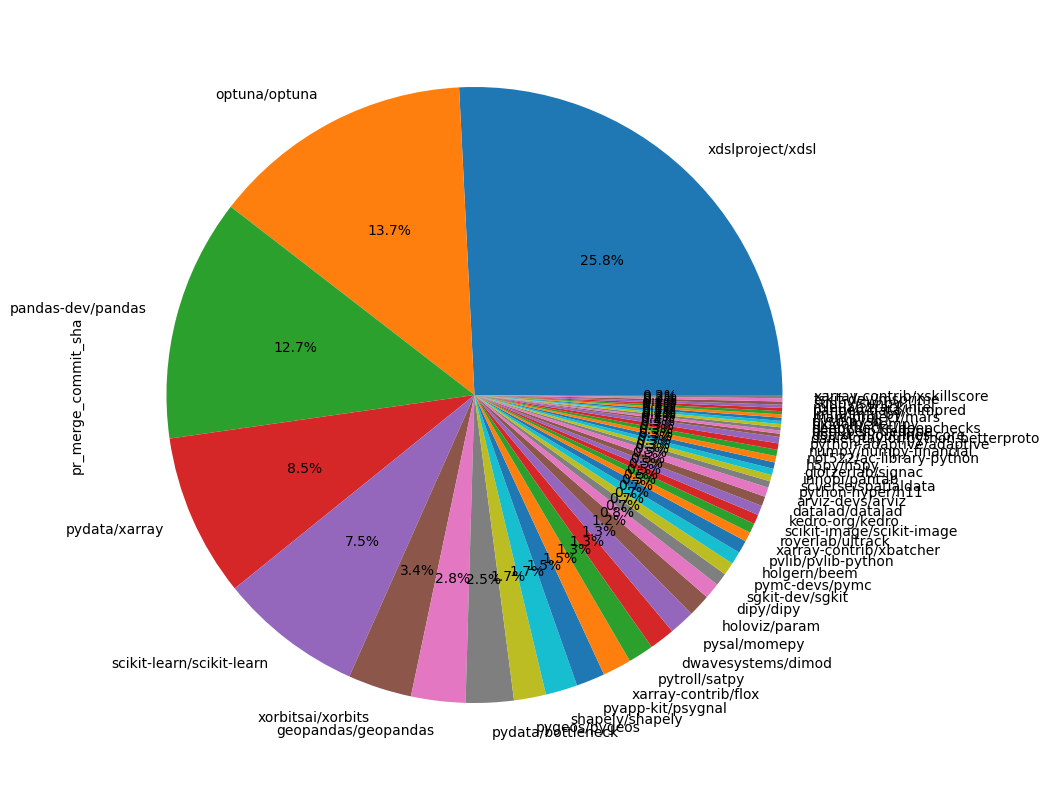

In [58]:
# print(fin_df.groupby('repo_name').agg({'pr_merge_commit_sha': 'nunique', 'date' : 'max', }).sort_values(by='pr_merge_commit_sha', ascending=False).to_markdown())


# Make a pie chart
fin_df.groupby("repo_name").agg({"pr_merge_commit_sha": "nunique"}).sort_values(
    by="pr_merge_commit_sha", ascending=False
).plot.pie(y="pr_merge_commit_sha", figsize=(10, 10), autopct="%1.1f%%", legend=False)

In [ ]:
uniq_df["difficulty"].apply(lambda s: s.split(",")[0].lower()).value_counts()

difficulty
medium                                                 499
easy                                                   442
n/a                                                     20
hard                                                    17
the difficulty level of this optimization is medium      1
Name: count, dtype: int64

<Axes: ylabel='count'>

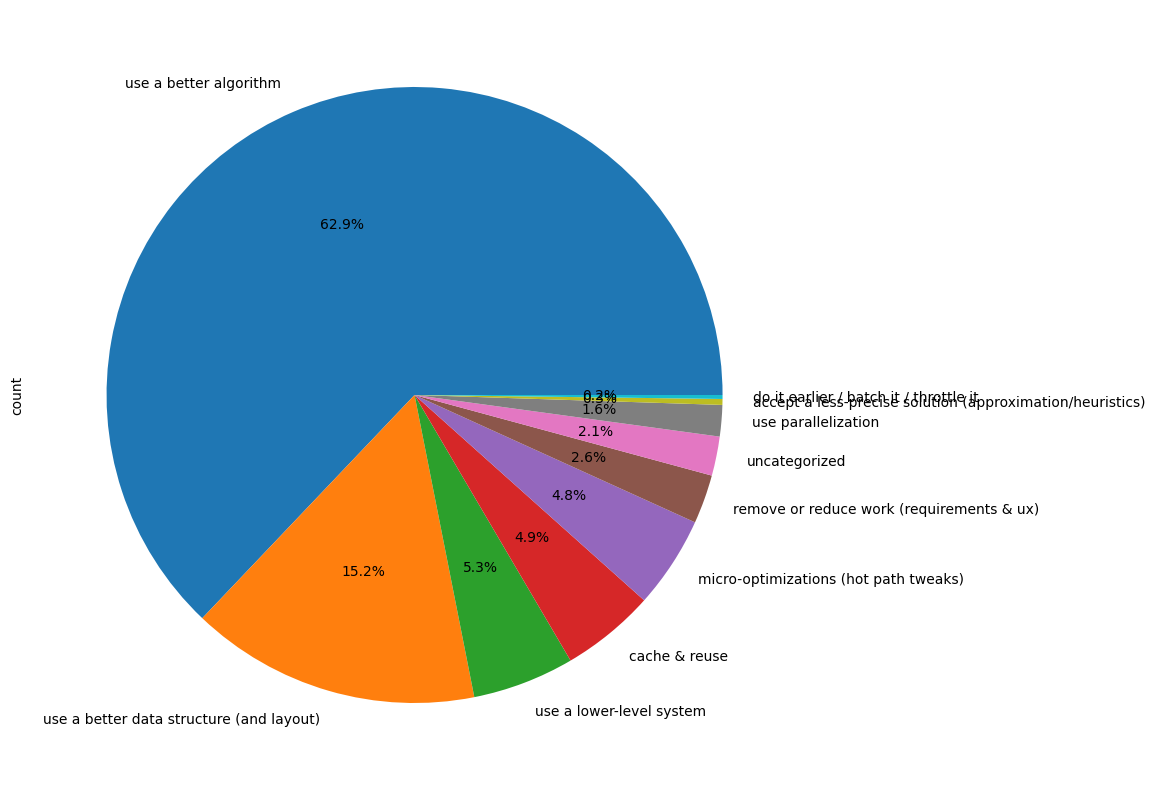

In [74]:
from datasmith.agents.summ_judge import OPTIMIZATION_CATEGORIES


def getcategory(raw_str: str) -> str:
    key = raw_str.split(":")[0].lower().replace("category ", "")
    if key.isdigit():
        return OPTIMIZATION_CATEGORIES.get(int(key), raw_str.split(":")[0].lower()).lower()
    return raw_str.split(":")[0].lower()


uniq_df["classification"].apply(getcategory).value_counts().iloc[:10].plot.pie(
    figsize=(10, 10), autopct="%1.1f%%", legend=False
)

/tmp/ipykernel_2882450/3225318762.py:114: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fin_df['country_candidates'] = fin_df['date'].apply(timezone_country_candidates)


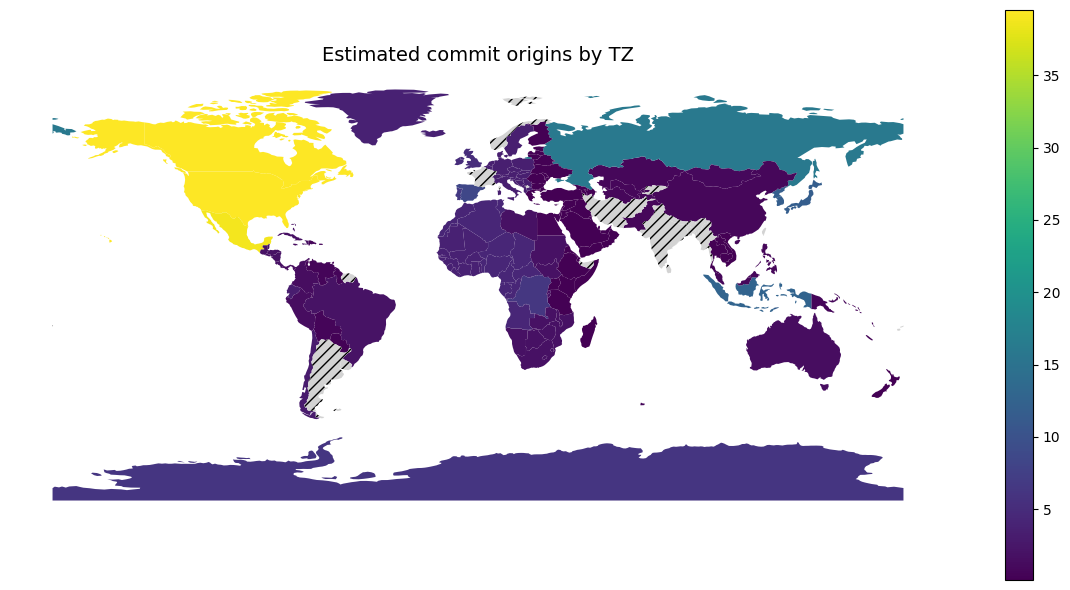

In [80]:
# pip install pandas numpy pytz pycountry geopandas matplotlib

from datetime import timezone
from functools import lru_cache

import pandas as pd


# ---------- 1) Country candidates from timezone offset (method #2) ----------
def timezone_country_candidates(x):
    """
    Return a list of ISO-2 country codes that had the same UTC offset
    as the timestamp x at that instant (DST-aware via pytz).

    Works with: fin_df['date'].apply(timezone_country_candidates)
    or        : fin_df.apply(timezone_country_candidates, axis=1)  (expects a 'date' column)
    """

    # Accept either a Series (row) with 'date' or a scalar string/Timestamp
    if isinstance(x, pd.Series):
        date_val = x["date"]
    else:
        date_val = x

    dt = pd.to_datetime(date_val, utc=False)
    if dt.tzinfo is None:
        dt = dt.tz_localize(timezone.utc)

    target_offset_min = int(dt.utcoffset().total_seconds() // 60)
    dt_utc = dt.tz_convert("UTC")
    key_date = dt_utc.floor("D").to_pydatetime()  # cache key

    return list(_countries_matching_offset_on_date(target_offset_min, key_date))


@lru_cache(maxsize=4096)
def _countries_matching_offset_on_date(offset_minutes, date_utc_midnight):
    import pytz

    if date_utc_midnight.tzinfo is None:
        date_utc_midnight = date_utc_midnight.replace(tzinfo=timezone.utc)

    hits = set()
    for cc, zones in pytz.country_timezones.items():
        for zname in zones:
            tz = pytz.timezone(zname)
            local_dt = date_utc_midnight.astimezone(tz)
            off = local_dt.utcoffset()
            if off is None:
                continue
            if int(off.total_seconds() // 60) == offset_minutes:
                hits.add(cc)
                break
    return tuple(sorted(hits))


# ---------- 2) Turn candidate lists into fractional row counts per country ----------
def build_country_counts(fin_df, candidates_col="country_candidates"):
    """
    Each row contributes 1/len(candidates) to each candidate country.
    Returns DataFrame with columns: cc (ISO-2), rows (float).
    """
    s = fin_df[candidates_col]
    lens = s.str.len().fillna(0).astype(int)
    mask = lens > 0
    exploded = s[mask].explode().reset_index(drop=True)
    weights = (1.0 / lens[mask]).repeat(lens[mask]).reset_index(drop=True)
    out = pd.DataFrame({"cc": exploded, "rows": weights}).groupby("cc", as_index=False)["rows"].sum()
    return out


# ---------- 3) Load world polygons (GeoPandas ≥1.0 friendly) ----------
def _load_world_admin0():
    """
    Reads Natural Earth's Admin-0 Countries (1:110m) directly from NACIS CDN.
    """
    import geopandas as gpd

    url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
    return gpd.read_file(url)  # GeoPandas can read zipped shapefiles from URLs


# ---------- 4) Plot choropleth by fractional row counts ----------
def plot_world_counts(country_counts_df, title="Estimated commit origins by TZ"):
    """
    Expects DataFrame with:
      - 'cc'   : ISO-2 country codes
      - 'rows' : fractional row count per country (float)
    """
    import matplotlib.pyplot as plt

    world = _load_world_admin0()

    # Join on ISO-2; Natural Earth typically names it 'ISO_A2'
    if "ISO_A2" not in world.columns:
        raise ValueError("Expected 'ISO_A2' in Natural Earth attributes; got columns: " + ", ".join(world.columns))

    df = country_counts_df.copy()
    df["ISO_A2"] = df["cc"]

    merged = world.merge(df, on="ISO_A2", how="left")

    ax = merged.plot(
        column="rows",
        legend=True,
        figsize=(12, 6),
        missing_kwds={"color": "lightgrey", "hatch": "///", "label": "No data"},
    )
    ax.set_title(title, fontsize=14)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


# ---------- 5) End-to-end usage ----------
fin_df["country_candidates"] = fin_df["date"].apply(timezone_country_candidates)
country_counts = build_country_counts(fin_df, "country_candidates")
plot_world_counts(country_counts)

In [17]:
print(len(shas_not_in_df))
print(uniq_df["pr_merge_commit_sha"].isin(shas_not_in_df).sum())
print(uniq_df["pr_base_sha"].isin(shas_not_in_df).sum())

271
164
63


In [5]:
task = Task(
    owner="pandas-dev",
    repo="pandas",
    sha="8b313d36aff97d28250bd6e8dad02c6da055f6f1",
    commit_date=1720632658.0,
    env_payload='{"constraints": [], "to_install": ["cython~=3.0.5", "fsspec==2024.2.0", "SQLAlchemy==2.0.27", "psycopg2-binary==2.9.9", "pyyaml", "pytest-cython", "meson[ninja]==1.2.1", "gitdb", "gitpython", "markdown", "numexpr==2.9.0", "types-PyMySQL", "natsort", "xlrd==2.0.1", "html5lib==1.1", "nbconvert==7.16.1", "pydata-sphinx-theme==0.14", "lxml==5.1.0", "types-PyYAML", "PyQt5==5.15.10", "beautifulsoup4==4.12.3", "jinja2==3.1.3", "nbsphinx", "moto", "nbformat", "pytest==8.0.2", "numpydoc", "odfpy==1.4.1", "qtpy==2.4.1", "zstandard==0.22.0", "tzdata==2024.1", "xlsxwriter==3.2.0", "py", "adbc-driver-postgresql==0.10.0", "types-python-dateutil", "dask", "flake8==6.1.0", "s3fs==2024.2.0", "google-auth", "pip", "types-pytz", "xarray==2024.2.0", "sphinx-copybutton", "requests", "pytest-cov", "ipykernel", "ipython", "scipy==1.12.0", "adbc-driver-sqlite==0.10.0", "python-dateutil==2.8.2", "pyreadstat==1.2.6", "pyarrow==11.0.0", "numpy<2", "matplotlib==3.8.3", "feedparser", "asv==0.6.3", "gcsfs==2024.2.0", "openpyxl==3.1.2", "pyxlsb==1.0.10", "pytz==2024.1", "hypothesis==6.98.15", "sphinx-design", "bottleneck==1.3.8", "python-calamine==0.2.0", "pytz", "pygments", "fastparquet==2024.2.0", "mypy==1.8.0", "tokenize-rt", "psycopg2==2.9.9", "python-dateutil", "pytest-xdist==3.5.0", "pandoc", "seaborn", "meson-python==0.13.1", "sphinx", "blosc", "numba==0.59.0", "coverage", "numpy==1.26.4", "pre-commit==3.6.2", "types-setuptools", "flask", "tabulate==0.9.0", "ipywidgets", "pymysql==1.1.0", "versioneer[toml]", "tables==3.9.2", "notebook==7.1.1"], "banned": ["pytest-qt"]}',
    tag="pkg",
)
ctx: DockerContext = registry.get(task)
# s3_config = S3CacheConfig(
#     bucket=os.environ["AWS_S3_BUCKET_DOCKER"],
#     prefix="docker-cache",
#     region=os.environ["AWS_REGION"],
#     max_cache_age_days=30,
#     max_cache_size_gb=100,
#     compression=True,
# )

# s3_cache_manager = S3DockerCacheManager(s3_config)

res = ctx.build_container_streaming(
    client=docker.from_env(),
    image_name=task.with_tag("pkg").get_image_name(),
    build_args={
        "REPO_URL": f"https://github.com/{task.owner}/{task.repo}.git",
        "COMMIT_SHA": task.sha,
        "ENV_PAYLOAD": task.env_payload,
    },
    run_labels={"notebook": "true"},
    s3_cache_config=None,
    force=False,
    use_buildx=False,
)

07:29:17 INFO     datasmith.docker.context: Docker image 'pandas-dev-pandas-8b313d36aff97d28250bd6e8dad02c6da055f6f1:pkg' found locally (skip build).
